In [1]:
import os
os.chdir("..")

In [2]:
from src.data_processing.size_dataset import ParticleDataset
from src.models.resnet import ResNet18
from src.trainers.trainersize import TrainerSize, generate_label_distribution
from torch.utils.data import DataLoader

In [3]:
# import os
# os.chdir("/nfshome/narjis")
dataset_path = "/nfshome/narjis/Downloads/brightfield_particles_y.hdf5"
classes = [0,1]
plot_dataset = ParticleDataset(
    h5_path=dataset_path,
    classes=classes,
    mean=None,
    std=None,
    padding=False,
    transform=None,
    indices=None,
)

Computed statistics: mean = 7541.1983, std = 1316.1215


In [5]:
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ResNet18(num_classes=1)  # For regression, output is a single value
# knn: /nfshome/narjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_2025-06-05_15-17-15/best_model.pth
# mmd: /nfshome/narjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_2025-06-11_11-09-50/best_model.pth
checkpoint_path = "/nfshome/narjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_2025-06-17_15-41-54/best_model.pth"
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device,weights_only=False)['model_state_dict'])
model = model.to(device)

Using cache found in /nfshome/narjis/.cache/torch/hub/pytorch_vision_v0.10.0


In [6]:
model.eval()
target_distribution = generate_label_distribution(num_points=30000, mean=302, std=25, min_value=150, max_value=None)
# images = [plot_dataset[i][0].unsqueeze(0) for i in range(len(plot_dataset))]
# images = torch.cat(images, dim=0).to(device)
dataloader = DataLoader(
        plot_dataset,
        batch_size=4000,
        drop_last=False,
    )

In [7]:
def contrast_from_middle_rows(images: torch.Tensor) -> torch.Tensor:
    """
    Compute standard deviation (RMS contrast) from the 4 middle rows of each image in a batch.
    
    Args:
        images: Tensor of shape (B, C, H, W)
    
    Returns:
        Tensor of shape (B,) with contrast values.
    """
    B, C, H, W = images.shape
    mid = H // 2
    rows = images[:, :, mid - 2:mid + 2, :]  # (B, C, 4, W)

    gray = rows.mean(dim=1)  # Convert to grayscale: (B, 4, W)
    contrast = gray.std(dim=(1, 2))  # Compute std over height and width

    return contrast  # shape: (B,)

In [9]:
import torch
from torch.utils.data import DataLoader
# Create DataLoader for the dataset
predictions = []
labels = []
contrasts = []
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    for batch,label in dataloader:
        images = batch.to(device)
        with torch.no_grad():
            outputs,_ = model(images)
            predictions.append(outputs.cpu().numpy().flatten())
        labels.append(label.numpy().flatten())
        contrasts.append(contrast_from_middle_rows(images))
    predictions = torch.cat([torch.tensor(pred) for pred in predictions], dim=0).numpy()
    labels = torch.cat([torch.tensor(label) for label in labels], dim=0).numpy()
    contrasts = torch.cat([contrast for contrast in contrasts], dim=0).cpu().numpy()

In [10]:
target_distribution[:30000].min()

tensor(10.1769)

In [11]:
target_distribution[30000:].min()

tensor(193.4759)

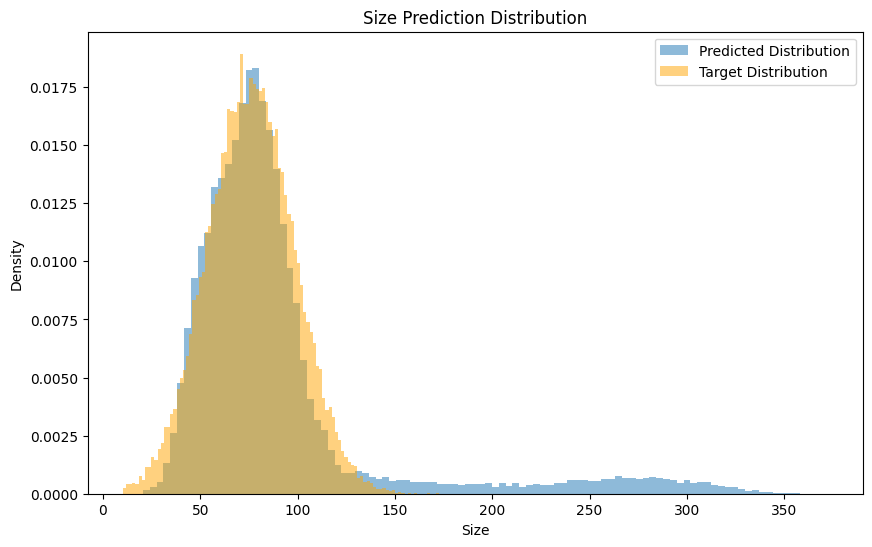

In [12]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(predictions[labels==0], bins=100, density=True, alpha=0.5, label='Predicted Distribution')
ax.hist(target_distribution[:30000], bins=100, density=True, alpha=0.5, label='Target Distribution', color='orange')
ax.set_title('Size Prediction Distribution')
ax.set_xlabel('Size')
ax.set_ylabel('Density')
ax.legend()
plt.show()

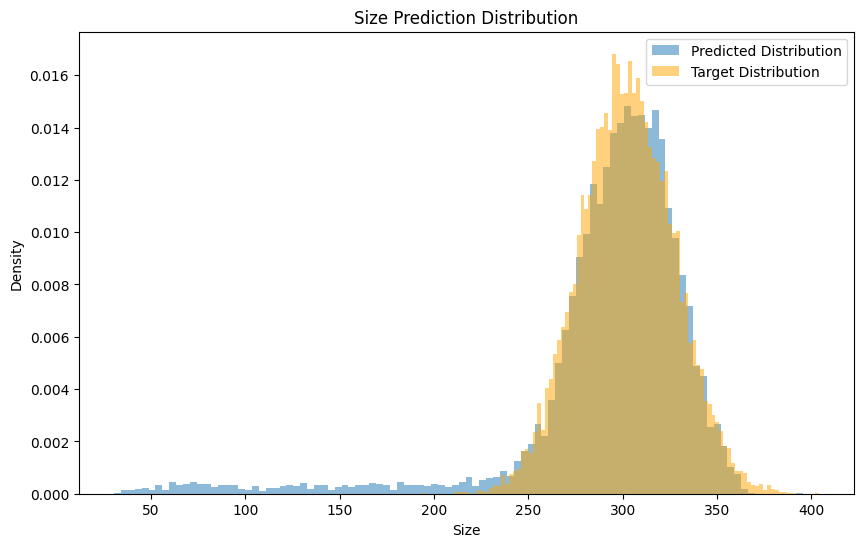

In [13]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(predictions[labels==1], bins=100, density=True, alpha=0.5, label='Predicted Distribution')
ax.hist(target_distribution[30000:], bins=100, density=True, alpha=0.5, label='Target Distribution', color='orange')
ax.set_title('Size Prediction Distribution')
ax.set_xlabel('Size')
ax.set_ylabel('Density')
ax.legend()
plt.show()

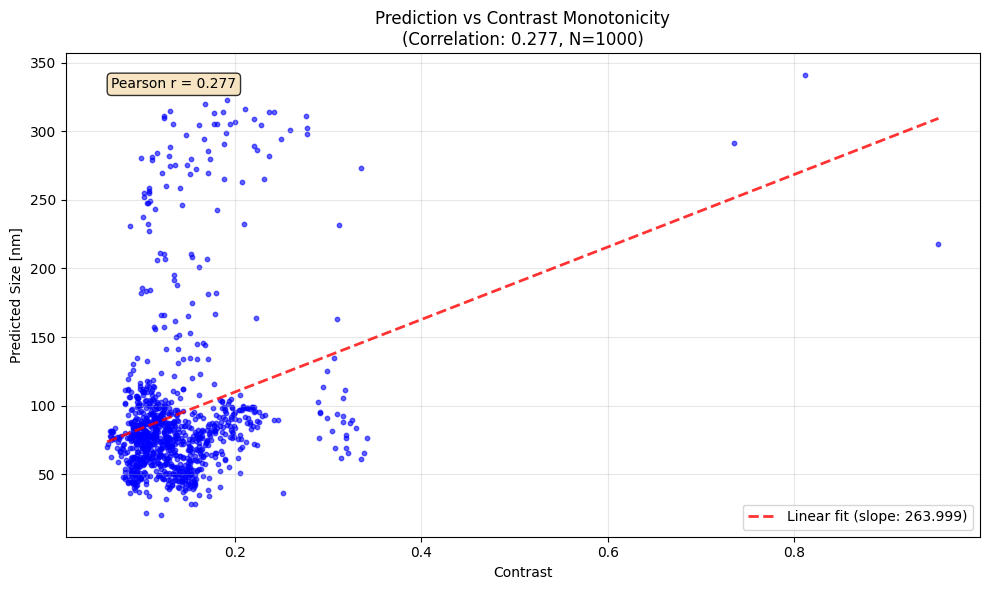

In [14]:
import numpy as np
random_indices = np.random.choice(np.where(labels==0)[0], size=1000, replace=False)
contrasts_80 = contrasts[random_indices]
predictions_80 = predictions[random_indices]
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
# Scatter plot
ax.scatter(contrasts_80, predictions_80, alpha=0.6, s=10, color='blue')

# Add trend line (polynomial fit)
z = np.polyfit(contrasts_80, predictions_80, 1)  # Linear fit
p = np.poly1d(z)
x_trend = np.linspace(contrasts_80.min(), contrasts_80.max(), 100)
ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label=f'Linear fit (slope: {z[0]:.3f})')

# Calculate correlation coefficient
correlation = np.corrcoef(contrasts_80, predictions_80)[0, 1]

ax.set_xlabel('Contrast')
ax.set_ylabel('Predicted Size [nm]')
ax.set_title(f'Prediction vs Contrast Monotonicity\n(Correlation: {correlation:.3f}, N={len(contrasts_80)})')
ax.legend()
ax.grid(True, alpha=0.3)

# Add correlation coefficient as text
ax.text(0.05, 0.95, f'Pearson r = {correlation:.3f}', 
        transform=ax.transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8),
        verticalalignment='top')

plt.tight_layout()

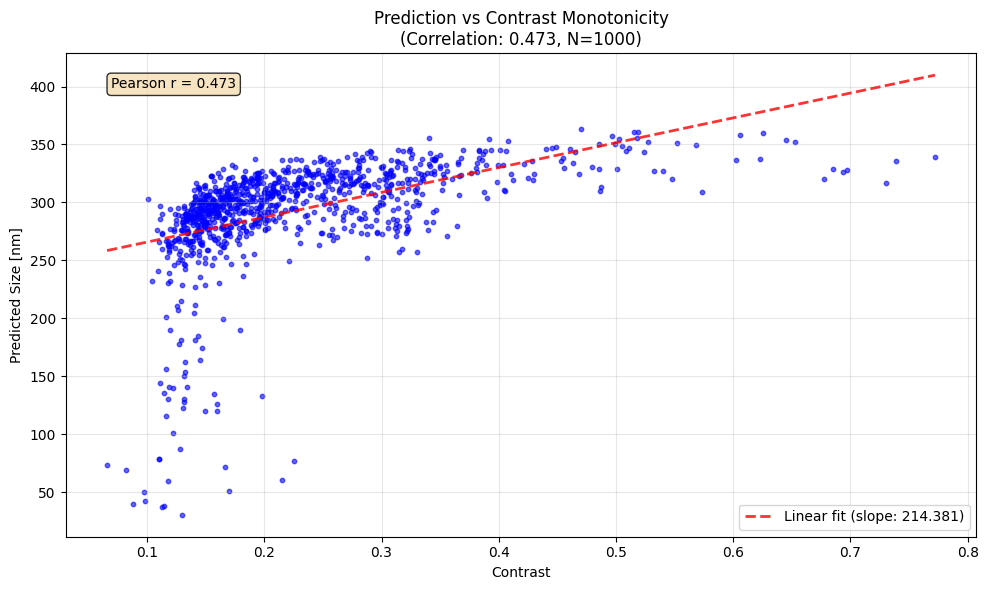

In [15]:
import numpy as np
random_indices = np.random.choice(np.where(labels==1)[0], size=1000, replace=False)
contrasts_80 = contrasts[random_indices]
predictions_80 = predictions[random_indices]
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
# Scatter plot
ax.scatter(contrasts_80, predictions_80, alpha=0.6, s=10, color='blue')

# Add trend line (polynomial fit)
z = np.polyfit(contrasts_80, predictions_80, 1)  # Linear fit
p = np.poly1d(z)
x_trend = np.linspace(contrasts_80.min(), contrasts_80.max(), 100)
ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label=f'Linear fit (slope: {z[0]:.3f})')

# Calculate correlation coefficient
correlation = np.corrcoef(contrasts_80, predictions_80)[0, 1]

ax.set_xlabel('Contrast')
ax.set_ylabel('Predicted Size [nm]')
ax.set_title(f'Prediction vs Contrast Monotonicity\n(Correlation: {correlation:.3f}, N={len(contrasts_80)})')
ax.legend()
ax.grid(True, alpha=0.3)

# Add correlation coefficient as text
ax.text(0.05, 0.95, f'Pearson r = {correlation:.3f}', 
        transform=ax.transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8),
        verticalalignment='top')

plt.tight_layout()

In [ ]:
import sys
import contextlib
import torch.nn.functional as F

def remove_all_hooks(model):
    """Removes all forward and backward hooks from the model."""
    for module in model.modules():  
        if hasattr(module, "_forward_hooks"):
            module._forward_hooks.clear()
        if hasattr(module, "_backward_hooks"):
            module._backward_hooks.clear()
        if hasattr(module, "_full_backward_hooks"):
            module._full_backward_hooks.clear()

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.feature_maps = None
        self.gradient = None
        
        self.target_layer.register_forward_hook(self._save_feature_maps)
        self.target_layer.register_full_backward_hook(self._save_gradient)
    
    def _save_feature_maps(self, module, input, output):
        self.feature_maps = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradient = grad_output[0].detach()
    
    def generate_heatmap(self, input_image, target_index=None):
        self.model.eval()
        
        # Get model prediction
        output = self.model(input_image)
        
        if target_index is None:
            target = output
        else:
            target = output[:, target_index]

        self.model.zero_grad()
        target.backward()
        
        # Calculate weights
        weights = torch.mean(self.gradient, dim=(2, 3), keepdim=True)
        
        # Generate weighted combination of feature maps
        cam = torch.sum(weights * self.feature_maps, dim=1, keepdim=True)
        
        # Apply ReLU
        cam = F.relu(cam)
        # Interpolate to match the width of the input image
        # Note: We're only interpolating the width (201) since height is different
        cam = F.interpolate(
            cam,
            size=(input_image.shape[2], input_image.shape[3]),  # (16, 201)
            mode='bicubic',
            align_corners=False
        )
        
        heatmap = cam.cpu().numpy()[0, 0]
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        
        return heatmap
    def remove_hooks(self):
        """Remove all registered hooks from the target layer."""
        if hasattr(self.target_layer, "_forward_hooks"):
            self.target_layer._forward_hooks.clear()
        if hasattr(self.target_layer, "_backward_hooks"):
            self.target_layer._backward_hooks.clear()
        if hasattr(self.target_layer, "_full_backward_hooks"):
            self.target_layer._full_backward_hooks.clear()

def apply_heatmap(image: np.ndarray, heatmap: np.ndarray, alpha: float = 0.5) -> np.ndarray:
    """
    Apply heatmap overlay to original image.
    15000
    Args:
        image: Original image (C, H, W) normalized
        heatmap: Heatmap array (H, W)
        alpha: Transparency factor for overlay
    """
    # Denormalize image to [0,1] range
    image = image.copy()
    for c in range(image.shape[0]):
        channel = image[c]
        channel_min, channel_max = channel.min(), channel.max()
        image[c] = (channel - channel_min) / (channel_max - channel_min)
    
    # Convert to (H, W, C)
    image = np.transpose(image, (1, 2, 0))
    
    # Convert heatmap to RGB (H, W, 3)
    heatmap_rgb = np.stack([heatmap, np.zeros_like(heatmap), np.zeros_like(heatmap)], axis=-1)
    
    # Create overlay
    overlay = image * (1 - alpha) + heatmap_rgb * alpha
    
    return overlay

def generate_RAM(model,image,traget_layer):    
    model.eval()
    grad_cam = GradCAM(model, target_layer=traget_layer) 
    with torch.no_grad():
        image_tensor = image.to(device).unsqueeze(0)  # Add batch dimension
    heatmap = grad_cam.generate_heatmap(image_tensor)
    grad_cam.remove_hooks()
    return heatmap

def plot_heatmap(image_tensor,heatmap):
    # Visualize
    plt.figure(figsize=(15, 4))
    # Original image - denormalize for visualization
    img = image_tensor.cpu().numpy()
    img_norm = np.zeros_like(img)
    for c in range(img.shape[0]):
        channel = img[c]
        channel_min, channel_max = channel.min(), channel.max()
        img_norm[c] = (channel - channel_min) / (channel_max - channel_min)
    plt.subplot(3, 1, 1)
    plt.imshow(np.transpose(img_norm, (1,2,0)),cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(3, 1, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title('Heatmap')
    plt.axis('off')
    plt.subplot(3, 1, 3)
    overlay = apply_heatmap(image_tensor.cpu().numpy(), heatmap)
    plt.imshow(overlay)
    plt.title('Overlay')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


remove_all_hooks(model)
target_layer =  model.resnet.layer3[0].conv1
# target_layer =  model.layer3[1].conv2
images = [plot_dataset[idx][0] for idx in range(9)]
heatmaps = [generate_RAM(model,image,target_layer) for image in images]
idx = 2
plot_heatmap(images[idx],heatmaps[idx])

In [ ]:
plt.imshow(images[0][0])

In [ ]:
model.resnet